In [1754]:
import vitaldb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("VitalDB is ready!")

VitalDB is ready!


In [1755]:
track_names = [
    "HR",
    "PLETH_SPO2",
    "RR_CO2",
    "ART_MBP"
]

caseids = vitaldb.find_cases(track_names)

print("Number of matching cases:", len(caseids))
print("First 10 case IDs:", caseids[:10])

C:\Users\samat\AppData\Local\Temp\ipykernel_27512\2553723723.py:8: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  caseids = vitaldb.find_cases(track_names)


Number of matching cases: 3730
First 10 case IDs: [1, 3, 4, 7, 10, 12, 13, 14, 16, 17]


In [1756]:
caseid = caseids[0]

print("Selected case:", caseid)

Selected case: 1


In [1757]:
values = vitaldb.load_case(
    caseid,
    track_names,
    interval=2
)

In [1758]:
print(type(values))
print(values.shape)

<class 'numpy.ndarray'>
(5772, 4)


In [1759]:
df_real = pd.DataFrame(
    values,
    columns=[
        "heart_rate",
        "spo2",
        "respiratory_rate",
        "mean_arterial_pressure"
    ]
)

df_real.head()

,heart_rate,spo2,respiratory_rate,mean_arterial_pressure
0,NaN,NaN,NaN,NaN
1,88.0,96.0,NaN,-8.0
2,87.0,96.0,NaN,-8.0
3,88.0,97.0,NaN,-8.0
4,88.0,96.0,NaN,-9.0


In [1760]:
df_real["time_seconds"] = np.arange(len(df_real)) * 2

df_real.head()

,heart_rate,spo2,respiratory_rate,mean_arterial_pressure,time_seconds
0,NaN,NaN,NaN,NaN,0
1,88.0,96.0,NaN,-8.0,2
2,87.0,96.0,NaN,-8.0,4
3,88.0,97.0,NaN,-8.0,6
4,88.0,96.0,NaN,-9.0,8


In [1761]:
df_real.head()

,heart_rate,spo2,respiratory_rate,mean_arterial_pressure,time_seconds
0,NaN,NaN,NaN,NaN,0
1,88.0,96.0,NaN,-8.0,2
2,87.0,96.0,NaN,-8.0,4
3,88.0,97.0,NaN,-8.0,6
4,88.0,96.0,NaN,-9.0,8


In [1762]:
df_real.shape

(5772, 5)

In [1763]:
df_real.columns

Index(['heart_rate', 'spo2', 'respiratory_rate', 'mean_arterial_pressure',
       'time_seconds'],
      dtype='str')

In [1764]:
df_real.info()

<class 'pandas.DataFrame'>
RangeIndex: 5772 entries, 0 to 5771
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   heart_rate              5455 non-null   float32
 1   spo2                    5496 non-null   float32
 2   respiratory_rate        4929 non-null   float32
 3   mean_arterial_pressure  5449 non-null   float32
 4   time_seconds            5772 non-null   int64  
dtypes: float32(4), int64(1)
memory usage: 135.4 KB


In [1765]:
df_real.describe()

,heart_rate,spo2,respiratory_rate,mean_arterial_pressure,time_seconds
count,5455.000000,5496.000000,4929.000000,5449.000000,5772.000000
mean,77.192665,98.730171,11.667681,81.859604,5771.000000
std,14.609980,1.807216,1.661592,42.272480,3332.754416
min,57.000000,77.000000,5.000000,-70.000000,0.000000
25%,68.000000,98.000000,10.000000,66.000000,2885.500000
50%,74.000000,99.000000,12.000000,80.000000,5771.000000
75%,82.000000,100.000000,13.000000,93.000000,8656.500000
max,139.000000,100.000000,14.000000,346.000000,11542.000000


In [1766]:
df_real.isnull().sum()

heart_rate                317
spo2                      276
respiratory_rate          843
mean_arterial_pressure    323
time_seconds                0
dtype: int64

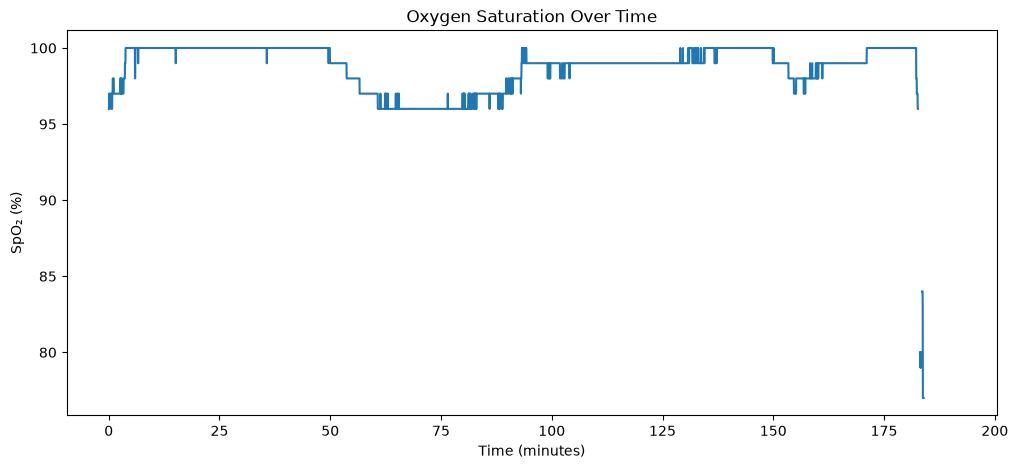

In [1767]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_real["time_seconds"] / 60,
    df_real["spo2"]
)

plt.xlabel("Time (minutes)")
plt.ylabel("SpO₂ (%)")
plt.title("Oxygen Saturation Over Time")

plt.show()

In [1768]:
from pathlib import Path

current_folder = Path.cwd()

if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder

raw_folder = project_root / "data" / "raw"
raw_folder.mkdir(parents=True, exist_ok=True)

raw_file = raw_folder / f"case_{caseid}_raw.csv"

df_real.to_csv(raw_file, index=False)

print("Saved to:")
print(raw_file)

Saved to:
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\data\raw\case_1_raw.csv


In [1769]:
df_real["time_minutes"] = df_real["time_seconds"] / 60

In [1770]:
df_real.head()

,heart_rate,spo2,respiratory_rate,mean_arterial_pressure,time_seconds,time_minutes
0,NaN,NaN,NaN,NaN,0,0.000000
1,88.0,96.0,NaN,-8.0,2,0.033333
2,87.0,96.0,NaN,-8.0,4,0.066667
3,88.0,97.0,NaN,-8.0,6,0.100000
4,88.0,96.0,NaN,-9.0,8,0.133333


In [1771]:
df_real.isnull().sum()

heart_rate                317
spo2                      276
respiratory_rate          843
mean_arterial_pressure    323
time_seconds                0
time_minutes                0
dtype: int64

In [1772]:
missing_report = pd.DataFrame({
    "missing_count": df_real.isnull().sum(),
    "missing_percent": (df_real.isnull().mean() * 100).round(2)
})

missing_report

,missing_count,missing_percent
heart_rate,317,5.49
spo2,276,4.78
respiratory_rate,843,14.60
mean_arterial_pressure,323,5.60
time_seconds,0,0.00
time_minutes,0,0.00


In [1773]:
df_real["spo2"].describe()

count    5496.000000
mean       98.730171
std         1.807216
min        77.000000
25%        98.000000
50%        99.000000
75%       100.000000
max       100.000000
Name: spo2, dtype: float64

In [1774]:
df_real.nsmallest(
    20,
    "spo2"
)[
    [
        "time_minutes",
        "spo2",
        "heart_rate",
        "respiratory_rate",
        "mean_arterial_pressure"
    ]
]

,time_minutes,spo2,heart_rate,respiratory_rate,mean_arterial_pressure
5513,183.766667,77.0,NaN,NaN,NaN
5514,183.800000,77.0,NaN,NaN,NaN
5515,183.833333,77.0,NaN,NaN,NaN
5516,183.866667,77.0,NaN,NaN,NaN
5517,183.900000,77.0,NaN,NaN,NaN
5518,183.933333,77.0,NaN,NaN,NaN
5496,183.200000,79.0,NaN,NaN,NaN
5499,183.300000,79.0,NaN,NaN,NaN
5493,183.100000,80.0,NaN,NaN,NaN
5494,183.133333,80.0,NaN,NaN,NaN


In [1775]:
invalid_spo2 = df_real[
    (df_real["spo2"] < 0) |
    (df_real["spo2"] > 100)
]

print("Invalid SpO2 rows:", len(invalid_spo2))

Invalid SpO2 rows: 0


In [1776]:
print("Total rows:", len(df_real))
print("Valid SpO2 rows:", df_real["spo2"].notna().sum())
print("Missing SpO2 rows:", df_real["spo2"].isna().sum())

Total rows: 5772
Valid SpO2 rows: 5496
Missing SpO2 rows: 276


In [1777]:
from pathlib import Path

current_folder = Path.cwd()

if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder

raw_folder = project_root / "data" / "raw"
raw_folder.mkdir(parents=True, exist_ok=True)

raw_file = raw_folder / f"case_{caseid}_raw.csv"

df_real.to_csv(raw_file, index=False)

print("Saved to:")
print(raw_file)

Saved to:
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\data\raw\case_1_raw.csv


In [1778]:
df_real["time_minutes"] = df_real["time_seconds"] / 60

In [1779]:
df_real.head()

,heart_rate,spo2,respiratory_rate,mean_arterial_pressure,time_seconds,time_minutes
0,NaN,NaN,NaN,NaN,0,0.000000
1,88.0,96.0,NaN,-8.0,2,0.033333
2,87.0,96.0,NaN,-8.0,4,0.066667
3,88.0,97.0,NaN,-8.0,6,0.100000
4,88.0,96.0,NaN,-9.0,8,0.133333


In [1780]:
missing_report = pd.DataFrame({
    "missing_count": df_real.isnull().sum(),
    "missing_percent": (df_real.isnull().mean() * 100).round(2)
})

missing_report

,missing_count,missing_percent
heart_rate,317,5.49
spo2,276,4.78
respiratory_rate,843,14.60
mean_arterial_pressure,323,5.60
time_seconds,0,0.00
time_minutes,0,0.00


In [1781]:
df_real["spo2"].describe()

count    5496.000000
mean       98.730171
std         1.807216
min        77.000000
25%        98.000000
50%        99.000000
75%       100.000000
max       100.000000
Name: spo2, dtype: float64

In [1782]:
df_real.nsmallest(
    20,
    "spo2"
)[
    [
        "time_minutes",
        "spo2",
        "heart_rate",
        "respiratory_rate",
        "mean_arterial_pressure"
    ]
]

,time_minutes,spo2,heart_rate,respiratory_rate,mean_arterial_pressure
5513,183.766667,77.0,NaN,NaN,NaN
5514,183.800000,77.0,NaN,NaN,NaN
5515,183.833333,77.0,NaN,NaN,NaN
5516,183.866667,77.0,NaN,NaN,NaN
5517,183.900000,77.0,NaN,NaN,NaN
5518,183.933333,77.0,NaN,NaN,NaN
5496,183.200000,79.0,NaN,NaN,NaN
5499,183.300000,79.0,NaN,NaN,NaN
5493,183.100000,80.0,NaN,NaN,NaN
5494,183.133333,80.0,NaN,NaN,NaN


In [1783]:
invalid_spo2 = df_real[
    (df_real["spo2"] < 0) |
    (df_real["spo2"] > 100)
]

print("Invalid SpO2 rows:", len(invalid_spo2))

Invalid SpO2 rows: 0


In [1784]:
missing_report = pd.DataFrame({
    "missing_count": df_real.isnull().sum(),
    "missing_percent": (df_real.isnull().mean() * 100).round(2)
})

missing_report

,missing_count,missing_percent
heart_rate,317,5.49
spo2,276,4.78
respiratory_rate,843,14.60
mean_arterial_pressure,323,5.60
time_seconds,0,0.00
time_minutes,0,0.00


In [1785]:
lowest_spo2 = df_real.nsmallest(
    20,
    "spo2"
)[
    [
        "time_minutes",
        "spo2",
        "heart_rate",
        "respiratory_rate",
        "mean_arterial_pressure"
    ]
]

lowest_spo2

,time_minutes,spo2,heart_rate,respiratory_rate,mean_arterial_pressure
5513,183.766667,77.0,NaN,NaN,NaN
5514,183.800000,77.0,NaN,NaN,NaN
5515,183.833333,77.0,NaN,NaN,NaN
5516,183.866667,77.0,NaN,NaN,NaN
5517,183.900000,77.0,NaN,NaN,NaN
5518,183.933333,77.0,NaN,NaN,NaN
5496,183.200000,79.0,NaN,NaN,NaN
5499,183.300000,79.0,NaN,NaN,NaN
5493,183.100000,80.0,NaN,NaN,NaN
5494,183.133333,80.0,NaN,NaN,NaN


In [1786]:
is_missing = df_real["spo2"].isna()

gap_group = (is_missing != is_missing.shift()).cumsum()

missing_gaps = (
    df_real[is_missing]
    .groupby(gap_group[is_missing])
    .agg(
        start_time=("time_minutes", "min"),
        end_time=("time_minutes", "max"),
        missing_rows=("spo2", "size")
    )
)

missing_gaps["gap_seconds"] = missing_gaps["missing_rows"] * 2

missing_gaps.sort_values(
    "missing_rows",
    ascending=False
).head(10)

,start_time,end_time,missing_rows,gap_seconds
spo2,,,,
9,183.966667,190.833333,207,414
11,190.900000,192.366667,45,90
5,182.666667,183.066667,13,26
3,181.866667,182.000000,5,10
7,183.400000,183.533333,5,10
1,0.000000,0.000000,1,2


In [1787]:
df_clean = df_real.copy()

In [1788]:
df_clean["minute"] = (
    df_clean["time_seconds"] // 60
).astype(int)

df_clean[
    ["time_seconds", "minute", "spo2"]
].head(35)

,time_seconds,minute,spo2
0,0,0,NaN
1,2,0,96.0
2,4,0,96.0
3,6,0,97.0
4,8,0,96.0
5,10,0,96.0
6,12,0,96.0
7,14,0,97.0
8,16,0,97.0
9,18,0,97.0


In [1789]:
df_minute = (
    df_clean
    .groupby("minute")
    .agg(
        heart_rate=("heart_rate", "median"),
        spo2=("spo2", "median"),
        respiratory_rate=("respiratory_rate", "median"),
        mean_arterial_pressure=(
            "mean_arterial_pressure",
            "median"
        ),
        spo2_valid_count=("spo2", "count"),
        samples_in_minute=("spo2", "size")
    )
    .reset_index()
)

df_minute.head()

,minute,heart_rate,spo2,respiratory_rate,mean_arterial_pressure,spo2_valid_count,samples_in_minute
0,0,79.0,97.0,NaN,-9.0,29,30
1,1,85.0,97.0,NaN,-9.0,30,30
2,2,88.0,97.0,NaN,-9.0,30,30
3,3,87.0,98.0,NaN,-9.0,30,30
4,4,86.0,100.0,NaN,-9.0,30,30


In [1790]:
df_minute["spo2_coverage"] = (
    df_minute["spo2_valid_count"] /
    df_minute["samples_in_minute"]
)

df_minute[
    [
        "minute",
        "spo2",
        "spo2_valid_count",
        "samples_in_minute",
        "spo2_coverage"
    ]
].head(20)

,minute,spo2,spo2_valid_count,samples_in_minute,spo2_coverage
0,0,97.0,29,30,0.966667
1,1,97.0,30,30,1.000000
2,2,97.0,30,30,1.000000
3,3,98.0,30,30,1.000000
4,4,100.0,30,30,1.000000
5,5,100.0,30,30,1.000000
6,6,100.0,30,30,1.000000
7,7,100.0,30,30,1.000000
8,8,100.0,30,30,1.000000
9,9,100.0,30,30,1.000000


In [1791]:
df_minute.sort_values(
    "spo2_coverage"
)[
    [
        "minute",
        "spo2",
        "spo2_valid_count",
        "samples_in_minute",
        "spo2_coverage"
    ]
].head(20)

,minute,spo2,spo2_valid_count,samples_in_minute,spo2_coverage
192,192,NaN,0,12,0.000000
188,188,NaN,0,30,0.000000
186,186,NaN,0,30,0.000000
184,184,NaN,0,30,0.000000
191,191,NaN,0,30,0.000000
189,189,NaN,0,30,0.000000
187,187,NaN,0,30,0.000000
185,185,NaN,0,30,0.000000
190,190,80.0,1,30,0.033333
182,182,98.0,19,30,0.633333


In [1792]:
low_coverage = df_minute["spo2_coverage"] < 0.50

df_minute.loc[
    low_coverage,
    "spo2"
] = np.nan

In [1793]:
print(
    "Minutes with low SpO2 coverage:",
    low_coverage.sum()
)

print(
    "Minutes with usable SpO2:",
    df_minute["spo2"].notna().sum()
)

Minutes with low SpO2 coverage: 9
Minutes with usable SpO2: 184


In [1794]:
print("Original rows:", len(df_real))
print("One-minute rows:", len(df_minute))

Original rows: 5772
One-minute rows: 193


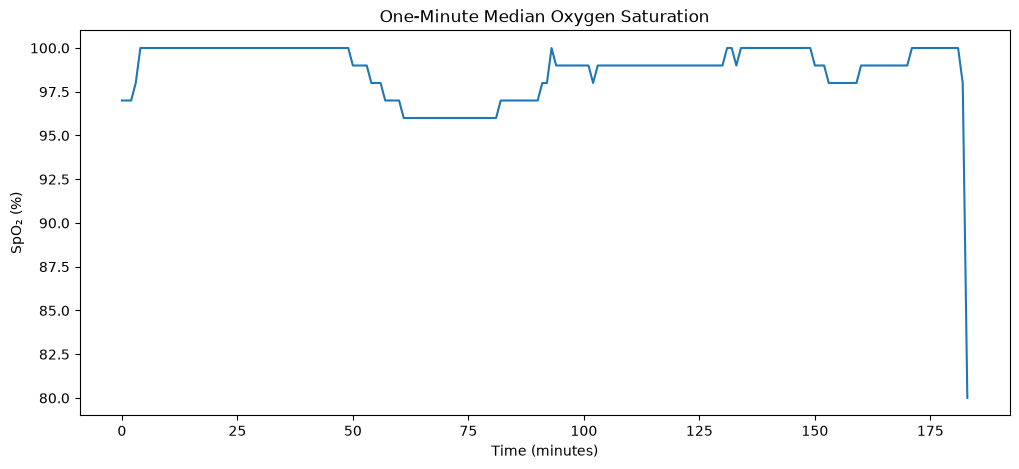

In [1795]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_minute["minute"],
    df_minute["spo2"]
)

plt.xlabel("Time (minutes)")
plt.ylabel("SpO₂ (%)")
plt.title("One-Minute Median Oxygen Saturation")

plt.show()

In [1796]:
processed_file = (
    project_root /
    "data" /
    "processed" /
    f"case_{caseid}_1min.csv"
)

df_minute.to_csv(
    processed_file,
    index=False
)

print("Processed data saved to:")
print(processed_file)

Processed data saved to:
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\data\processed\case_1_1min.csv


In [1797]:
df_minute.head()

,minute,heart_rate,spo2,respiratory_rate,mean_arterial_pressure,spo2_valid_count,samples_in_minute,spo2_coverage
0,0,79.0,97.0,NaN,-9.0,29,30,0.966667
1,1,85.0,97.0,NaN,-9.0,30,30,1.000000
2,2,88.0,97.0,NaN,-9.0,30,30,1.000000
3,3,87.0,98.0,NaN,-9.0,30,30,1.000000
4,4,86.0,100.0,NaN,-9.0,30,30,1.000000


In [1798]:
df_minute.sort_values(
    "spo2_coverage"
).head(20)

,minute,heart_rate,spo2,respiratory_rate,mean_arterial_pressure,spo2_valid_count,samples_in_minute,spo2_coverage
192,192,NaN,NaN,NaN,NaN,0,12,0.000000
188,188,NaN,NaN,NaN,NaN,0,30,0.000000
186,186,NaN,NaN,NaN,NaN,0,30,0.000000
184,184,NaN,NaN,NaN,NaN,0,30,0.000000
191,191,NaN,NaN,NaN,NaN,0,30,0.000000
189,189,NaN,NaN,NaN,NaN,0,30,0.000000
187,187,NaN,NaN,NaN,NaN,0,30,0.000000
185,185,NaN,NaN,NaN,NaN,0,30,0.000000
190,190,NaN,NaN,NaN,NaN,1,30,0.033333
182,182,103.0,98.0,NaN,NaN,19,30,0.633333


In [1799]:
print("Original rows:", len(df_real))
print("One-minute rows:", len(df_minute))

Original rows: 5772
One-minute rows: 193


In [1800]:
print("Minimum values:")
print()

print("Heart Rate:", df_minute["heart_rate"].min())
print("SpO2:", df_minute["spo2"].min())
print("Respiratory Rate:", df_minute["respiratory_rate"].min())
print("Mean Arterial Pressure:", df_minute["mean_arterial_pressure"].min())

Minimum values:

Heart Rate: 58.0
SpO2: 80.0
Respiratory Rate: 5.5
Mean Arterial Pressure: -9.0


In [1801]:
df_model = df_minute.copy()

In [1802]:
df_model.loc[
    df_model["heart_rate"] <= 0,
    "heart_rate"
] = np.nan

df_model.loc[
    (df_model["spo2"] < 0) |
    (df_model["spo2"] > 100),
    "spo2"
] = np.nan

df_model.loc[
    df_model["respiratory_rate"] < 0,
    "respiratory_rate"
] = np.nan

df_model.loc[
    df_model["mean_arterial_pressure"] <= 0,
    "mean_arterial_pressure"
] = np.nan

In [1803]:
print("Minimum values after basic cleaning:")
print()

print("Heart Rate:", df_model["heart_rate"].min())
print("SpO2:", df_model["spo2"].min())
print("Respiratory Rate:", df_model["respiratory_rate"].min())
print(
    "Mean Arterial Pressure:",
    df_model["mean_arterial_pressure"].min()
)

Minimum values after basic cleaning:

Heart Rate: 58.0
SpO2: 80.0
Respiratory Rate: 5.5
Mean Arterial Pressure: 2.5


In [1804]:
model_missing_report = pd.DataFrame({
    "missing_count": df_model.isnull().sum(),
    "missing_percent": (
        df_model.isnull().mean() * 100
    ).round(2)
})

model_missing_report

,missing_count,missing_percent
minute,0,0.00
heart_rate,10,5.18
spo2,9,4.66
respiratory_rate,26,13.47
mean_arterial_pressure,22,11.40
spo2_valid_count,0,0.00
samples_in_minute,0,0.00
spo2_coverage,0,0.00


In [1805]:
print("Total one-minute rows:", len(df_model))
print()

print(
    "Heart Rate available:",
    df_model["heart_rate"].notna().sum()
)

print(
    "SpO2 available:",
    df_model["spo2"].notna().sum()
)

print(
    "Respiratory Rate available:",
    df_model["respiratory_rate"].notna().sum()
)

print(
    "Mean Arterial Pressure available:",
    df_model["mean_arterial_pressure"].notna().sum()
)

Total one-minute rows: 193

Heart Rate available: 183
SpO2 available: 184
Respiratory Rate available: 167
Mean Arterial Pressure available: 171


In [1806]:
df_model["future_spo2_5min"] = (
    df_model["spo2"].shift(-5)
)

In [1807]:
df_model["future_spo2_5min"] = (
    df_model["spo2"].shift(-5)
)

In [1808]:
df_model[
    [
        "minute",
        "spo2",
        "future_spo2_5min"
    ]
].head(15)

,minute,spo2,future_spo2_5min
0,0,97.0,100.0
1,1,97.0,100.0
2,2,97.0,100.0
3,3,98.0,100.0
4,4,100.0,100.0
5,5,100.0,100.0
6,6,100.0,100.0
7,7,100.0,100.0
8,8,100.0,100.0
9,9,100.0,100.0


In [1809]:
df_model[
    [
        "minute",
        "spo2",
        "future_spo2_5min"
    ]
].tail(10)

,minute,spo2,future_spo2_5min
183,183,80.0,NaN
184,184,NaN,NaN
185,185,NaN,NaN
186,186,NaN,NaN
187,187,NaN,NaN
188,188,NaN,NaN
189,189,NaN,NaN
190,190,NaN,NaN
191,191,NaN,NaN
192,192,NaN,NaN


In [ ]:
print(
    "Rows with future target:",
    df_model["future_spo2_5min"].notna().sum()
)

print(
    "Rows without future target:",
    df_model["future_spo2_5min"].isna().sum()
)

Rows with future target: 179
Rows without future target: 14


: 